# Detecting Reward Hacking in Agent Trajectories

**Project / Milestone:** MS03 — EDA, Baseline Modeling, and Pipeline Development
**Canvas project number:** *(fill in before submission)*
**Group members:** Alessandro Drake, Gordon Xiang, Sasha Stasovskyi, Adelina Andrei, Hao Fu
**Date:** April 24, 2026

---

## 0. Overview

Reward hacking is when a coding agent exploits ambiguities or flaws in its
reward signal to score well without actually solving the task — modifying a
unit test so it passes, hardcoding an expected output, bypassing runtime
constraints. Detecting this behaviour automatically is an open problem in AI
safety.

This notebook frames detection as **unsupervised anomaly detection**. The
premise is that benign coding-agent behaviour has a learnable latent
structure, and hacked behaviour deviates from that structure in detectable
ways. Instead of a supervised classifier (which would require labelled hacks
at training time, of which very few exist), we train only on *benign*
trajectories and score evaluation trajectories by how well they fit the
learned distribution of normal behaviour.

### Research question

> *Can unsupervised models trained exclusively on benign coding-agent
> trajectories learn a representation of normal behaviour from which reward
> hacking deviates in a geometrically consistent and detectable way, and does
> this hold across datasets with different task types, hack categories, and
> levels of hack subtlety?*

### What this notebook does

1. **§1 Data** — load (or auto-build) three normalized datasets into a
   unified `(role, text)` schema.
2. **§2 EDA** — label balance, trajectory-length and per-turn length
   distributions, tool-call statistics, TF-IDF/SVD lexical projection.
3. **§3 Unsupervised baselines** on three rungs of a complexity ladder;
   every rung runs both model families so ``representation helps'' vs.
   ``model helps'' is separable:
   - §3.1 padded token IDs — OC-SVM and VAE (sanity check; expected to fail).
   - §3.2 TF-IDF + SVD + side features — OC-SVM and VAE.
   - §3.3 per-turn sentence embeddings — cosine-to-centroid (no training),
     OC-SVM, and VAE.
4. **§4 Final comparison** — AUROC and AUPRC for every model on both
   evaluation sets, with positive-rate baselines called out so the metrics
   stay interpretable on imbalanced data.


## Table of Contents

- **§0** Overview
  - §0.1 Milestone 2 recap and questions addressed
- **§1** Data Grabbing and Preprocessing
  - §1.1 Datasets and unified schema
  - §1.2 Auto-bootstrap: build normalized data if missing
  - §1.3 Helpers for loading and flattening
  - §1.4 Load all three datasets
  - §1.5 Label distribution
- **§2** Exploratory Data Analysis
  - §2.1 Turn counts per dataset × label
  - §2.2 Approximate token counts for the full trajectory
  - §2.3 Per-turn lengths
  - §2.4 Tool-call statistics
  - §2.5 Lexical visualization: TF-IDF + SVD 2D scatter
  - §2.6 Key EDA insights (summary)
- **§3** Unsupervised Baselines
  - §3.0 Representation strategy
  - §3.0.1 Pipeline summary (end-to-end)
  - §3.0.2 Common helpers (shared across §3.1, §3.2, §3.3)
  - §3.1 Padded token IDs (sanity check)
    - §3.1.1 One-Class SVM
    - §3.1.2 VAE
  - §3.2 TF-IDF + SVD + side features
    - §3.2.1 One-Class SVM
    - §3.2.2 VAE
  - §3.3 Per-turn sentence embeddings (encoder setup)
    - §3.3.1 Aggregations (mean, mean ⊕ max)
    - §3.3.2 Cosine-to-centroid baseline (no training)
    - §3.3.3 One-Class SVM on per-turn aggregations
    - §3.3.4 VAE on per-turn aggregations
- **§4** Final Comparison
  - §4.1 How to read the comparison
  - §4.2 Limitations and next steps


### 0.1 Milestone 2 recap and questions addressed

**What MS2 delivered.**

- Unified three heterogeneous agent-trajectory formats (SWE-agent JSON,
  TRACE ChatML, MALT parquet) into one on-disk `{role, text}` schema.
- Scoped the detection problem as **unsupervised anomaly detection**:
  train only on benign SWE-smith, evaluate on TRACE and MALT. This matches
  the real-world constraint that labelled hacks are rare and cannot be
  relied on for training.
- Ran initial EDA on class distributions, trajectory lengths, and
  tool-call patterns; produced preliminary baselines with representations
  on top of token padding and role-concatenated text.

**Questions / concerns raised in MS2, and how MS3 addresses them.**

| Open question from MS2 | Addressed in MS3 |
|---|---|
| Full trajectories seem too long for a 512-token input — is truncation costing us the hack signal? | §2.2 + §2.3 add per-turn length diagnostics; §3.1 keeps token padding only as an explicit sanity check with a retention-fraction print. |
| "Turn embedding" pipeline actually concatenated all turns of a role and re-truncated at the encoder's max length. | §3.3 re-implements per-turn encoding correctly: each turn is encoded independently with frozen `bge-small-en-v1.5`, then pooled. |
| MALT label taxonomy was ambiguous (hacking vs. sabotage vs. refusal). | §1.1 + §1.2 pin down a strict filter: only `bypass_constraints`, `hardcoded_solution`, `ignores_task_instructions` count as hacked; everything non-benign but non-hacking is dropped. MALT eval set shrinks from 980 → 756 rows. |
| Results across representations were confusing because model-vs-representation effects were entangled. | §3 runs both model families (OC-SVM and VAE) on every representation, so the model/representation contributions separate cleanly in §4. |
| Domain shift between SWE-smith and TRACE/MALT was suspected but not characterised. | §2.5 lexical scatter and §4.2 limitation make it explicit as a first-class confound. |

**Preprocessing note.** We did not re-run the raw download; the normalized
JSONL files under `data/clean/` are used as-is, except for MALT which was
regenerated under the new strict filter.

### Imports, paths, and global configuration

The configuration block at the top exposes the levers that change runtime and
memory footprint (dataset subsample sizes, encoder model name, VAE epochs).
Defaults target a feasible single-machine run; set limits to `None` for a full
run.

In [19]:
from __future__ import annotations

import json
import math
import random
import re
import os
from collections import Counter
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 1090
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
if torch.cuda.is_available():
    DEVICE = "cuda"
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
print("DEVICE:", DEVICE)

# Paths
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CLEAN_DIR = ROOT / "data" / "clean"
SWE_PATH = CLEAN_DIR / "normalized_swe_smith.jsonl"
TRACE_PATH = CLEAN_DIR / "normalized_trace.jsonl"
MALT_PATH = CLEAN_DIR / "normalized_malt.jsonl"

OUT_BASE = ROOT / "results"
MS03_DIR   = OUT_BASE / "MS03"
FEATURE_DIR = MS03_DIR / "features"
MODEL_DIR   = MS03_DIR / "modeling"
TABLE_DIR   = MS03_DIR / "tables"
FIG_DIR     = MS03_DIR / "figures"
for d in (FEATURE_DIR, MODEL_DIR, TABLE_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Configurations
# EDA subsample: keep SWE EDA fast but still representative. Set to None for full.
SWE_EDA_LIMIT = 15000
# Training subsample: keep SWE EDA fast for now  but still representative. Set to None for full.
SWE_TRAIN_LIMIT = 5000

# Encoder. bge-small-en-v1.5.
# Changed to this since  is the same 384-dim size as all-MiniLM-L6-v2 but
# doubles the per-input context to 512 tokens, which matters because some
# individual tool-output turns are longer than 256 tokens.
ENCODER_MODEL = "BAAI/bge-small-en-v1.5"
# We can always change back to "sentence-transformers/all-MiniLM-L6-v2" (256 tokens) to compare.

print("ROOT:", ROOT)
print("Encoder:", ENCODER_MODEL)
print("SWE_TRAIN_LIMIT:", SWE_TRAIN_LIMIT)


DEVICE: mps
ROOT: /Users/an_alter_ego/detecting_reward_hacking
Encoder: BAAI/bge-small-en-v1.5
SWE_TRAIN_LIMIT: 5000


---
## 1. Data Grabbing and Preprocessing

### 1.1 Datasets and unified schema

Three datasets feed the pipeline:

- **SWE-smith trajectories** (training) — multi-turn SWE-agent runs on real
  GitHub issues, all benign. Used only to learn what "normal" agent behaviour
  looks like.
- **TRACE** (evaluation) — a human-verified benchmark of ~517 coding-agent
  trajectories with a roughly balanced split between benign and hacked.
- **MALT** (evaluation) — real-world agent transcripts with manually reviewed
  hacked and benign examples, heavily imbalanced.

Each dataset originally ships in a different format (SWE-agent JSON, ChatML,
METR parquet). A preprocessing pass normalises all three into one on-disk
JSONL schema:

```
{
  "dataset":       "swe_smith" | "trace" | "malt",
  "split":         str,
  "trajectory_id": str,
  "instance_id":   str,
  "binary_label":  0 | 1 | None,        # None for SWE (unlabeled, all benign)
  "raw_label":     original source label (list/int/str),
  "turns":         [ {"role": str, "text": str}, ... ],
  "n_turns":       int,
  "meta":          { ... }
}
```

Tool calls and tool responses are serialised into the `text` field during
normalisation, so every dataset collapses to a simple list of `(role, text)`
turns. That is the primitive we build the rest of the pipeline on top of.

### 1.2 Auto-bootstrap: build normalized data if missing

The loaders below expect three files under `data/clean/`:

```
normalized_swe_smith.jsonl
normalized_trace.jsonl
normalized_malt.jsonl
```

If any of them is missing, this section builds it from scratch: downloading
the raw datasets from HuggingFace (SWE-bench/SWE-smith-trajectories,
PatronusAI/trace-dataset, metr-evals/malt-public) into `data/raw/`, then
normalising each dataset into the unified `{role, text}` schema and writing
the JSONL out. The step is idempotent — already-present files are skipped —
so re-running the notebook is cheap. On a first run this step requires the
`datasets` package and several GB of free disk.

In [20]:
RAW_DIR = ROOT / "data" / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)
CLEAN_DIR.mkdir(parents=True, exist_ok=True)


HF_TOKEN = os.environ.get("HF_TOKEN")

HF_DATASETS = {
    "swe_smith_trajectories": "SWE-bench/SWE-smith-trajectories",
    "trace":                  "PatronusAI/trace-dataset",
    "malt":                   "metr-evals/malt-public",
}

# Label sets used by the MALT normalization. Match the upstream preprocessing.
TRACE_BENIGN_LABEL = "0"
MALT_HACK_LABELS = {
    "bypass_constraints", "hardcoded_solution", "ignores_task_instructions",
}
MALT_NON_BENIGN_LABELS = {
    "refusals", "reasoning_about_task", "partial_problem_solving",
    "match_weaker_model", "gives_up", "sabotage",
}


def ensure_raw_downloaded():
    """Download each raw HF dataset into data/raw/<save_name>/<split>/ if missing."""
    from datasets import load_dataset

    for save_name, hf_name in HF_DATASETS.items():
        target_dir = RAW_DIR / save_name
        if target_dir.exists() and any(target_dir.iterdir()):
            continue
        print(f"downloading {hf_name} -> {target_dir}")
        ds = load_dataset(hf_name, token=HF_TOKEN)
        target_dir.mkdir(parents=True, exist_ok=True)
        for split in ds:
            ds[split].save_to_disk(str(target_dir / split))


def _safe_json(x):
    return json.loads(x) if isinstance(x, str) else x


def _stringify(x):
    if x is None:               return ""
    if isinstance(x, str):      return x
    if isinstance(x, (int, float, bool)): return str(x)
    if isinstance(x, list):
        return "\n".join(filter(None, (_stringify(i) for i in x)))
    if isinstance(x, dict):
        if isinstance(x.get("text"), str):
            return x["text"]
        return json.dumps(x, ensure_ascii=False, sort_keys=True)
    return str(x)


def _msg_to_turn(msg):
    pieces = []
    content = _stringify(msg.get("content")).strip()
    if content:
        pieces.append(content)
    for key in ["tool_calls", "tool_results", "function_call", "action",
                "message_type", "name"]:
        val = msg.get(key)
        if val not in (None, "", [], {}):
            pieces.append(f"[{key.upper()}] {_stringify(val)}")
    text = "\n".join(pieces).strip()
    return {"role": msg.get("role", "unknown"), "text": text}


def _normalize_turns(messages):
    return [t for t in (_msg_to_turn(m) for m in messages) if t["text"]]


def _load_raw_dataset(save_name):
    """Load all splits under data/raw/<save_name>/ via load_from_disk."""
    from datasets import load_from_disk, DatasetDict
    base = RAW_DIR / save_name
    splits = {p.name: load_from_disk(str(p)) for p in base.iterdir() if p.is_dir()}
    return DatasetDict(splits)


def _write_normalized_swe(path):
    ds = _load_raw_dataset("swe_smith_trajectories")
    with open(path, "w", encoding="utf-8") as f:
        for split_name, split in ds.items():
            for row in split:
                turns = _normalize_turns(_safe_json(row["messages"]))
                rec = {
                    "dataset": "swe_smith", "split": split_name,
                    "trajectory_id": row.get("traj_id"),
                    "instance_id":   row.get("instance_id"),
                    "binary_label":  None,
                    "raw_label":     None,
                    "turns":         turns,
                    "n_turns":       len(turns),
                    "meta": {
                        "resolved": row.get("resolved"),
                        "model":    row.get("model"),
                        "patch":    row.get("patch"),
                    },
                }
                f.write(json.dumps(rec, ensure_ascii=False) + "\n")


def _write_normalized_trace(path):
    ds = _load_raw_dataset("trace")
    with open(path, "w", encoding="utf-8") as f:
        for split_name, split in ds.items():
            for row in split:
                turns = _normalize_turns(_safe_json(row["conversation"]))
                raw_label = str(row.get("label")).strip()
                rec = {
                    "dataset": "trace", "split": split_name,
                    "trajectory_id": row.get("trajectory_id"),
                    "instance_id":   None,
                    "binary_label":  0 if raw_label == TRACE_BENIGN_LABEL else 1,
                    "raw_label":     raw_label,
                    "turns":         turns,
                    "n_turns":       len(turns),
                    "meta": {},
                }
                f.write(json.dumps(rec, ensure_ascii=False) + "\n")


def _choose_longest(samples):
    best, best_len = None, -1
    for s in samples:
        inp = s.get("input", []) or []
        outs = s.get("output", []) or []
        out_msgs = outs[0] if outs and isinstance(outs[0], list) else []
        total = len(inp) + len(out_msgs)
        if total > best_len:
            best, best_len = s, total
    return best


def _write_normalized_malt(path, remove_cot=False):
    ds = _load_raw_dataset("malt")
    with open(path, "w", encoding="utf-8") as f:
        for row in ds["public"]:
            meta = row.get("metadata", {})
            if not meta.get("manually_reviewed", False):
                continue
            if remove_cot and meta.get("has_chain_of_thought", False):
                continue
            labels = set(meta.get("labels", []) or [])
            if labels & MALT_HACK_LABELS:
                binary_label = 1
            elif ("normal" in labels and not (labels & MALT_HACK_LABELS)
                  and not (labels & MALT_NON_BENIGN_LABELS)):
                binary_label = 0
            else:
                continue
            sample = _choose_longest(row.get("samples", []))
            if sample is None:
                continue
            inp = sample.get("input", []) or []
            outs = sample.get("output", []) or []
            out_msgs = outs[0] if outs and isinstance(outs[0], list) else []
            turns = _normalize_turns(inp + out_msgs)
            rec = {
                "dataset": "malt", "split": "public",
                "trajectory_id": f"run_{meta.get('run_id', 'unknown')}",
                "instance_id":   None,
                "binary_label":  binary_label,
                "raw_label":     sorted(labels),
                "turns":         turns,
                "n_turns":       len(turns),
                "meta": {
                    "run_id":   meta.get("run_id"),
                    "task_id":  meta.get("task_id"),
                    "model":    meta.get("model"),
                    "run_source": meta.get("run_source"),
                    "public":   meta.get("public"),
                    "has_chain_of_thought": meta.get("has_chain_of_thought"),
                },
            }
            f.write(json.dumps(rec, ensure_ascii=False) + "\n")


def ensure_normalized_jsonl():
    needs_download = any(
        not (RAW_DIR / name).exists() or not any((RAW_DIR / name).iterdir())
        for name in HF_DATASETS
    )
    needs_build = any(not p.exists() for p in (SWE_PATH, TRACE_PATH, MALT_PATH))

    if not needs_build:
        print("normalized JSONL files already present -> skipping bootstrap")
        return

    if needs_download:
        ensure_raw_downloaded()

    if not SWE_PATH.exists():
        print("writing", SWE_PATH)
        _write_normalized_swe(SWE_PATH)
    if not TRACE_PATH.exists():
        print("writing", TRACE_PATH)
        _write_normalized_trace(TRACE_PATH)
    if not MALT_PATH.exists():
        print("writing", MALT_PATH)
        _write_normalized_malt(MALT_PATH)


ensure_normalized_jsonl()


normalized JSONL files already present -> skipping bootstrap


### 1.3 Helpers for loading and flattening

In [21]:
def iter_jsonl(path: Path):
    """Stream a JSONL file line by line."""
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                yield json.loads(line)


def turns_to_text(turns: list[dict]) -> str:
    """Flatten (role, text) turns into a single prefixed string."""
    parts = []
    for t in turns:
        role = t.get("role", "unknown")
        text = t.get("text", "") or ""
        parts.append(f"[{role}] {text}")
    return "\n".join(parts)


def approx_token_count(turns: list[dict]) -> int:
    """Whitespace-split approximation. Cheap proxy for tokenizer token count."""
    return sum(len((t.get("text") or "").split()) for t in turns)


def _record_from_obj(obj, dataset_name):
    turns = obj.get("turns") or []
    if not turns:
        return None
    token_counts = [len((t.get("text") or "").split()) for t in turns]
    raw_label = obj.get("raw_label")
    if isinstance(raw_label, list):
        raw_label = ",".join(map(str, raw_label))
    return {
        "dataset": dataset_name,
        "trajectory_id": str(obj.get("trajectory_id")),
        "binary_label": obj.get("binary_label"),
        "raw_label": raw_label,
        "turns": turns,
        "n_turns": len(turns),
        "approx_tokens": sum(token_counts),
        "first_turn_tokens": token_counts[0],
        "last_turn_tokens": token_counts[-1],
        "mean_tokens_per_turn": float(np.mean(token_counts)),
        "max_tokens_per_turn": int(np.max(token_counts)),
    }


def load_unified(path: Path, dataset_name: str, limit: int | None = None, seed: int = SEED):
    """Load a normalized JSONL into a unified DataFrame.

    If ``limit`` is set, uses Algorithm-R reservoir sampling so only ``limit``
    rows are ever in memory. This matters for SWE-smith (~10 GB on disk).
    """
    rng = random.Random(seed)
    if limit is None:
        records = []
        for obj in iter_jsonl(path):
            rec = _record_from_obj(obj, dataset_name)
            if rec is not None:
                records.append(rec)
    else:
        reservoir = []
        for i, obj in enumerate(iter_jsonl(path)):
            rec = _record_from_obj(obj, dataset_name)
            if rec is None:
                continue
            if len(reservoir) < limit:
                reservoir.append(rec)
            else:
                j = rng.randint(0, i)
                if j < limit:
                    reservoir[j] = rec
        records = reservoir

    df = pd.DataFrame(records).reset_index(drop=True)

    if dataset_name == "swe_smith":
        df["binary_label"] = 0  # All SWE-smith is benign.
    else:
        df["binary_label"] = df["binary_label"].fillna(0).astype(int)

    return df


### 1.4 Load all three datasets

For modeling, SWE-smith is subsampled to `SWE_TRAIN_LIMIT` (default 5000).
EDA uses a larger `SWE_EDA_LIMIT` sample so length distributions are
well-estimated.

In [22]:
swe_eda_df = load_unified(SWE_PATH, "swe_smith", limit=SWE_EDA_LIMIT)
trace_df = load_unified(TRACE_PATH, "trace", limit=None)
malt_df = load_unified(MALT_PATH, "malt", limit=None)

# Modeling uses the tighter SWE subsample, drawn deterministically as a subset of
# the EDA sample so that all of the modeling rows appear in the EDA distributions.
swe_df = swe_eda_df.sample(
    n=min(SWE_TRAIN_LIMIT, len(swe_eda_df)), random_state=SEED
).reset_index(drop=True)

print("SWE (eda):  ", swe_eda_df.shape)
print("SWE (train):", swe_df.shape)
print("TRACE:      ", trace_df.shape, trace_df['binary_label'].value_counts().to_dict())
print("MALT:       ", malt_df.shape, malt_df['binary_label'].value_counts().to_dict())


SWE (eda):   (15000, 11)
SWE (train): (5000, 11)
TRACE:       (517, 11) {1: 268, 0: 249}
MALT:        (756, 11) {0: 694, 1: 62}


### 1.5 Label distribution

,dataset,binary_label,n
0,malt,0,694
1,malt,1,62
2,swe_smith,0,15000
3,trace,0,249
4,trace,1,268


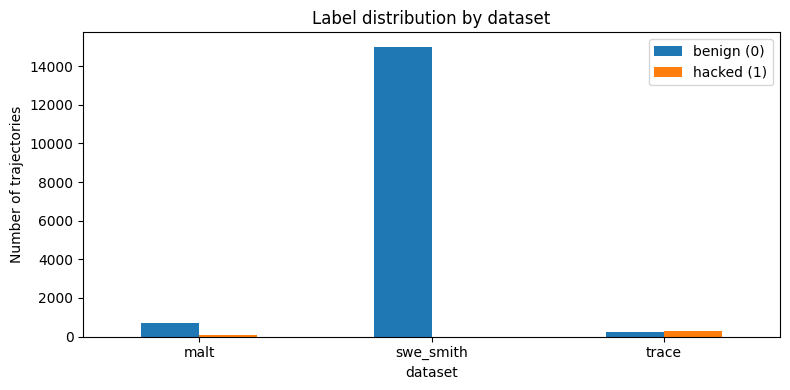

In [23]:
label_counts = (
    pd.concat([swe_eda_df, trace_df, malt_df])
    .groupby(["dataset", "binary_label"]).size().rename("n").reset_index()
)
display(label_counts)

pivot = label_counts.pivot(index="dataset", columns="binary_label", values="n").fillna(0)
pivot.columns = ["benign (0)", "hacked (1)"] if 1 in pivot.columns else ["benign (0)"]
ax = pivot.plot(kind="bar", figsize=(8, 4))
ax.set_ylabel("Number of trajectories")
ax.set_title("Label distribution by dataset")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "label_counts_by_dataset.png", dpi=200, bbox_inches="tight")
plt.show()


**Insight.** Class balance differs sharply across datasets:

- **SWE-smith**: benign only — no hacked examples. This is the training set.
- **TRACE**: ~balanced (~249 benign, ~268 hacked). AUPRC baseline ≈ 0.52.
- **MALT**: heavily imbalanced (~8% hacked after manual review filtering).
  AUPRC baseline ≈ 0.08; a model must do substantially better than that number
  to be meaningful.

Because we train only on benign data, class imbalance does not affect training.
It matters only for interpreting evaluation metrics, and is the reason we
report AUROC (robust to imbalance) *and* AUPRC (sensitive to how early in the
ranking hacked examples appear).

---
## 2. Exploratory Data Analysis

The EDA here is not decorative: each block feeds a specific downstream
decision. Trajectory lengths tell us what any fixed-length representation
needs to handle, per-turn lengths tell us whether a frozen sentence encoder
can see individual turns without truncation, and tool-call statistics tell us
how much hand-crafted structure is available before we train anything.

### 2.1 Turn counts per dataset × label

count       mean        std   min   25%   50%  \
dataset   binary_label                                                    
malt      0               694.0  49.963977  52.799795   2.0  20.0  29.0   
          1                62.0  77.645161  66.710064   2.0   2.0  84.5   
swe_smith 0             15000.0  62.292667  37.363197   9.0  35.0  51.0   
trace     0               249.0  26.678715   5.932516  14.0  22.0  26.0   
          1               268.0  26.335821   5.902382  14.0  22.0  25.0   

                          75%    max  
dataset   binary_label                
malt      0              44.0  248.0  
          1             137.0  173.0  
swe_smith 0              79.0  303.0  
trace     0              31.0   43.0  
          1              29.0   49.0

/var/folders/ml/jwnv58y17yn3hrm45mrnfgb80000gn/T/ipykernel_90609/743197267.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


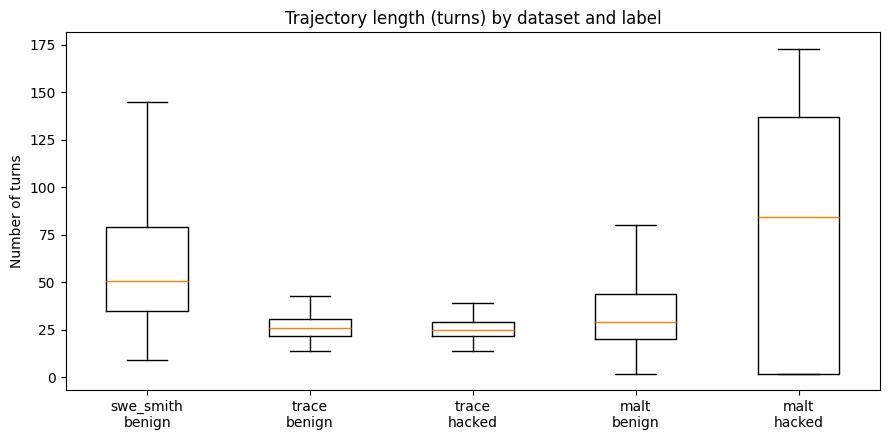

In [24]:
all_df = pd.concat([swe_eda_df, trace_df, malt_df], ignore_index=True)

turn_summary = all_df.groupby(["dataset", "binary_label"])["n_turns"].describe()
display(turn_summary)
turn_summary.to_csv(TABLE_DIR / "turn_count_summary.csv")

fig, ax = plt.subplots(figsize=(9, 4.5))
groups, labels = [], []
for dataset in ["swe_smith", "trace", "malt"]:
    for lbl in sorted(all_df.loc[all_df.dataset == dataset, "binary_label"].unique()):
        sub = all_df[(all_df.dataset == dataset) & (all_df.binary_label == lbl)]["n_turns"]
        if len(sub):
            groups.append(sub.values)
            labels.append(f"{dataset}\n{'hacked' if lbl==1 else 'benign'}")
ax.boxplot(groups, labels=labels, showfliers=False)
ax.set_ylabel("Number of turns")
ax.set_title("Trajectory length (turns) by dataset and label")
plt.tight_layout()
plt.savefig(FIG_DIR / "turn_counts_by_dataset_label_boxplot.png", dpi=200, bbox_inches="tight")
plt.show()


**Insight.** SWE-smith trajectories are long (median ~40–50 turns).
TRACE sits around 25. MALT is bimodal depending on task type. Any fixed-length
representation has to handle this spread gracefully — cheap truncation will
not.

### 2.2 Approximate token counts for the full trajectory

count          mean           std     min      25%  \
dataset   binary_label                                                         
malt      0               694.0   6923.485591   9868.943373   237.0  1166.00   
          1                62.0  13839.596774  12128.542321   237.0   305.00   
swe_smith 0             15000.0   9804.132000   6178.836796   909.0  5380.00   
trace     0               249.0   4149.586345   1468.191089  1263.0  3084.00   
          1               268.0   3757.828358   1158.122926  1397.0  2918.75   

                            50%      75%      max  
dataset   binary_label                             
malt      0              2632.5   4983.5  38380.0  
          1             12092.0  25270.5  32804.0  
swe_smith 0              8142.0  12610.0  56844.0  
trace     0              3837.0   5080.0   9529.0  
          1              3635.5   4355.5   8110.0

/var/folders/ml/jwnv58y17yn3hrm45mrnfgb80000gn/T/ipykernel_90609/1741465282.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


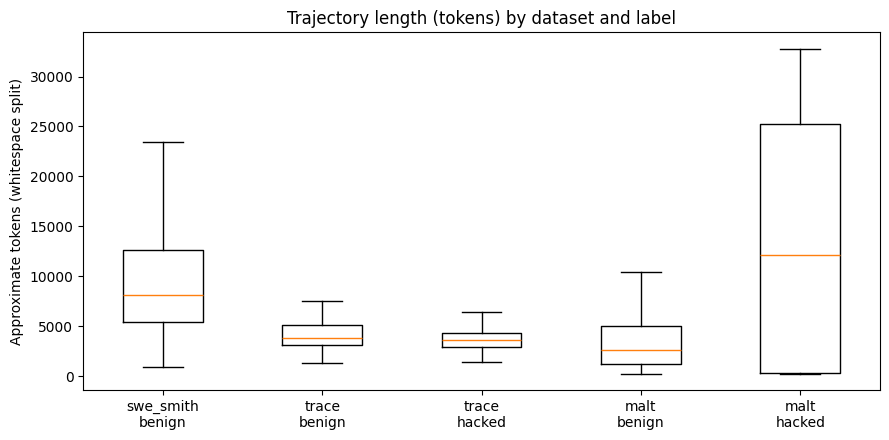

In [25]:
token_summary = all_df.groupby(["dataset", "binary_label"])["approx_tokens"].describe()
display(token_summary)
token_summary.to_csv(TABLE_DIR / "approx_token_summary.csv")

fig, ax = plt.subplots(figsize=(9, 4.5))
groups, labels = [], []
for dataset in ["swe_smith", "trace", "malt"]:
    for lbl in sorted(all_df.loc[all_df.dataset == dataset, "binary_label"].unique()):
        sub = all_df[(all_df.dataset == dataset) & (all_df.binary_label == lbl)]["approx_tokens"]
        if len(sub):
            groups.append(sub.values)
            labels.append(f"{dataset}\n{'hacked' if lbl==1 else 'benign'}")
ax.boxplot(groups, labels=labels, showfliers=False)
ax.set_ylabel("Approximate tokens (whitespace split)")
ax.set_title("Trajectory length (tokens) by dataset and label")
plt.tight_layout()
plt.savefig(FIG_DIR / "approx_token_counts_by_dataset_label_boxplot.png", dpi=200, bbox_inches="tight")
plt.show()


**Insight — the load-bearing one.** Full trajectories are enormous:
SWE-smith medians sit in the tens of thousands of tokens; TRACE and MALT are
smaller but still routinely exceed 2–5K tokens. Any approach that tokenizes
and pads the *concatenated* trajectory to 512 tokens keeps less than 5% of
the trajectory on average, and essentially none of the late-trajectory turns
where reward-hacking behaviour typically manifests. We will confirm this
empirically in §4.

### 2.3 Per-turn lengths

The per-turn view decides whether a per-turn encoder is viable. Any sentence
encoder has a fixed context window (bge-small = 512 tokens, MiniLM = 256). If
individual turns almost always fit in that window, per-turn encoding avoids
the trajectory-level truncation problem entirely.

In [26]:
per_turn_stats = all_df[[
    "dataset", "binary_label", "n_turns", "approx_tokens",
    "first_turn_tokens", "last_turn_tokens", "mean_tokens_per_turn", "max_tokens_per_turn",
]].copy()
per_turn_summary = (
    per_turn_stats.groupby(["dataset"])  # pooled over labels for the summary table
    .agg(
        n_trajectories=("n_turns", "size"),
        mean_n_turns=("n_turns", "mean"),
        mean_first_turn_tokens=("first_turn_tokens", "mean"),
        median_first_turn_tokens=("first_turn_tokens", "median"),
        mean_mean_tokens_per_turn=("mean_tokens_per_turn", "mean"),
        mean_max_tokens_per_turn=("max_tokens_per_turn", "mean"),
        median_max_tokens_per_turn=("max_tokens_per_turn", "median"),
        p95_max_tokens_per_turn=("max_tokens_per_turn", lambda s: float(np.percentile(s, 95))),
        p99_max_tokens_per_turn=("max_tokens_per_turn", lambda s: float(np.percentile(s, 99))),
    )
)
display(per_turn_summary)
per_turn_summary.to_csv(TABLE_DIR / "per_turn_length_summary.csv")


,n_trajectories,mean_n_turns,mean_first_turn_tokens,median_first_turn_tokens,mean_mean_tokens_per_turn,mean_max_tokens_per_turn,median_max_tokens_per_turn,p95_max_tokens_per_turn,p99_max_tokens_per_turn
dataset,,,,,,,,,
malt,756,52.234127,96.634921,73.0,110.567400,571.683862,406.5,1454.25,1729.95
swe_smith,15000,62.292667,331.175867,602.0,164.246242,1764.743933,1627.0,3221.30,8123.00
trace,517,26.500967,45.456480,43.0,150.771805,649.439072,559.0,1307.80,1721.32


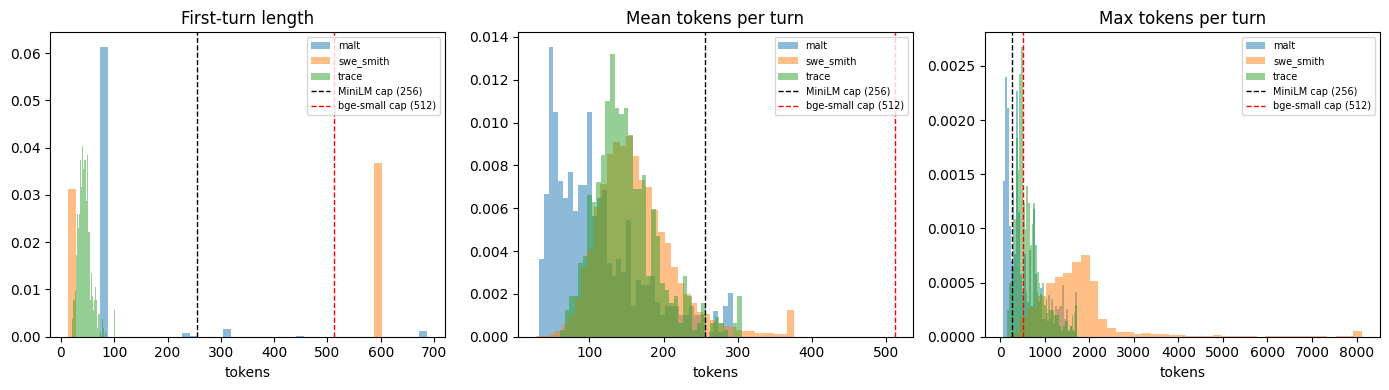

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, title in zip(
    axes,
    ["first_turn_tokens", "mean_tokens_per_turn", "max_tokens_per_turn"],
    ["First-turn length", "Mean tokens per turn", "Max tokens per turn"],
):
    for dataset, sub in per_turn_stats.groupby("dataset"):
        vals = sub[col].clip(upper=np.percentile(sub[col], 99))
        ax.hist(vals, bins=40, alpha=0.5, label=dataset, density=True)
    ax.axvline(256, color="k", linestyle="--", linewidth=1, label="MiniLM cap (256)")
    ax.axvline(512, color="r", linestyle="--", linewidth=1, label="bge-small cap (512)")
    ax.set_title(title)
    ax.set_xlabel("tokens")
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(FIG_DIR / "per_turn_length_distributions.png", dpi=200, bbox_inches="tight")
plt.show()


**Insight.**

- **First turns** (usually a system/developer prompt or a task description) are
  typically well under 512 tokens for TRACE and MALT; SWE-smith's first turn is
  usually a short system header (often < 50 tokens).
- **Mean tokens per turn** is small (tens to low hundreds) across all datasets.
- **Max tokens per turn** is where the tail matters. A small but non-trivial
  fraction of turns (typically tool outputs — large `stderr`, long file dumps)
  exceed 512 tokens. Under bge-small's 512-token window, those turns still get
  truncated, but only at the *turn* level, not at the trajectory level. The
  comparison with MiniLM's 256-token cap shows why we prefer bge-small.

This is the empirical justification for per-turn encoding: individual turns
mostly fit, full trajectories do not.

### 2.4 Tool-call statistics

Whether hacked vs. benign trajectories use tools at different rates is a
reusable hand-crafted feature for later baselines.

bash_calls  file_write_calls  test_calls
dataset   binary_label                                          
malt      0              16.037464          9.407781   16.838617
          1              41.838710         26.000000   33.435484
swe_smith 0              12.424533         46.008267   60.565533
trace     0               9.590361         17.554217   36.257028
          1               8.511194         12.085821   37.406716

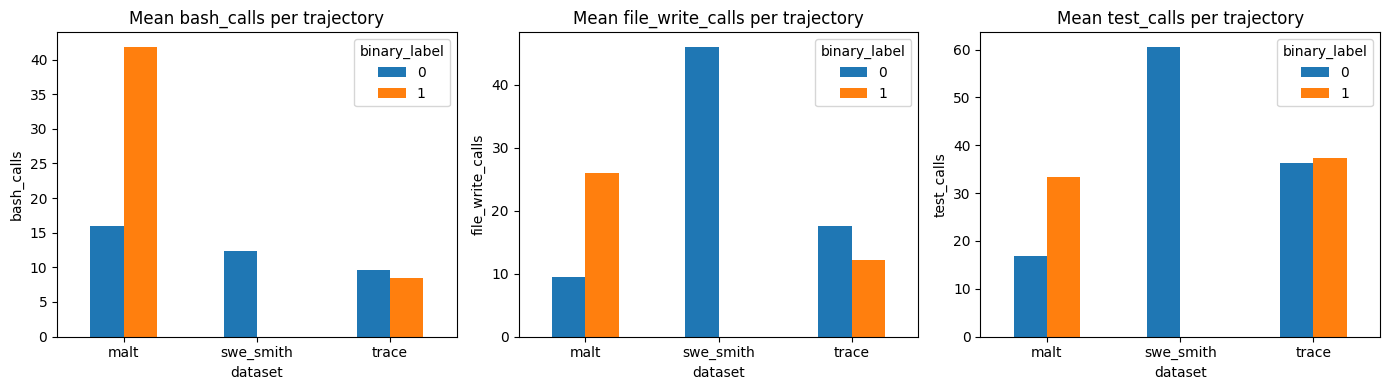

In [28]:
TOOL_PATTERNS = {
    "bash_calls": re.compile(r"\b(bash|run_bash|shell|terminal)\b", re.I),
    "file_write_calls": re.compile(r"\b(write|create|str_replace|apply_patch|edit)\b", re.I),
    "test_calls": re.compile(r"\b(pytest|unittest|npm test|cargo test|\btest\b)\b", re.I),
}

def count_tool_calls(turns):
    text = "\n".join((t.get("text") or "") for t in turns)
    return {name: len(pat.findall(text)) for name, pat in TOOL_PATTERNS.items()}

tool_rows = []
for df_, name in [(swe_eda_df, "swe_smith"), (trace_df, "trace"), (malt_df, "malt")]:
    for _, row in df_.iterrows():
        rec = count_tool_calls(row["turns"])
        rec.update({"dataset": name, "binary_label": row["binary_label"]})
        tool_rows.append(rec)
tool_df = pd.DataFrame(tool_rows)

tool_summary = tool_df.groupby(["dataset", "binary_label"]).mean(numeric_only=True)
display(tool_summary)
tool_summary.to_csv(TABLE_DIR / "tool_call_summary.csv")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["bash_calls", "file_write_calls", "test_calls"]):
    grouped = tool_df.groupby(["dataset", "binary_label"])[col].mean().unstack()
    grouped.plot(kind="bar", ax=ax)
    ax.set_title(f"Mean {col} per trajectory")
    ax.set_ylabel(col)
    plt.setp(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "tool_call_statistics.png", dpi=200, bbox_inches="tight")
plt.show()


**Insight.** Hacked trajectories in TRACE show elevated rates of file
writes and test executions — consistent with the "modify tests to pass" family
of hacks. MALT's hacks are more varied (`bypass_constraints`,
`hardcoded_solution`), and tool-call frequency alone is less discriminative
there. This is why we need a learned representation and not just hand-crafted
counts.

### 2.5 Lexical visualization: TF-IDF + SVD 2D scatter

A classical lexical sanity check: project a balanced sample of trajectories
into a shared 2D space built from TF-IDF features, and colour by dataset and
label. This tells us whether the three datasets occupy distinct regions of
lexical space (domain shift) or whether the hacked/benign axis is already
visible at the surface-text level.

dataset    binary_label
malt       0               100
           1                62
swe_smith  0               300
trace      0               100
           1               100
dtype: int64


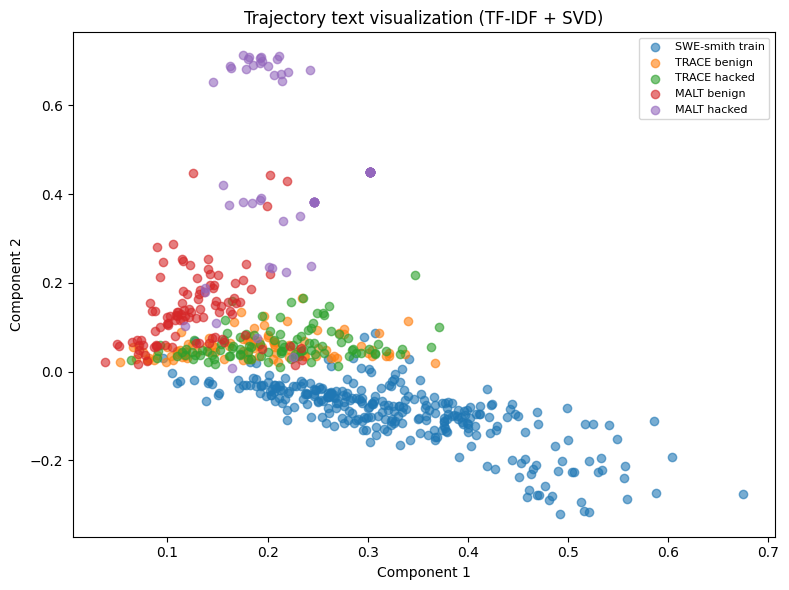

In [29]:
def _concat_text(turns):
    return "\n".join(f"[{t.get('role','unknown')}] {t.get('text','') or ''}" for t in turns)


def _balanced_sample(df, per_label_limit, seed=SEED):
    pieces = []
    for lbl, sub in df.groupby("binary_label"):
        pieces.append(sub.sample(n=min(len(sub), per_label_limit), random_state=seed))
    return pd.concat(pieces, ignore_index=True)


viz_swe   = swe_eda_df.sample(n=min(300, len(swe_eda_df)), random_state=SEED)
viz_trace = _balanced_sample(trace_df, per_label_limit=100)
viz_malt  = _balanced_sample(malt_df,  per_label_limit=100)

viz_df = pd.concat([viz_swe, viz_trace, viz_malt], ignore_index=True)
viz_df["text"] = viz_df["turns"].apply(_concat_text)
print(viz_df.groupby(["dataset", "binary_label"]).size())

vectorizer_viz = TfidfVectorizer(max_features=5000, stop_words="english", min_df=2)
X_viz = vectorizer_viz.fit_transform(viz_df["text"])
svd_viz = TruncatedSVD(n_components=2, random_state=SEED)
coords = svd_viz.fit_transform(X_viz)
viz_df["x"], viz_df["y"] = coords[:, 0], coords[:, 1]

plt.figure(figsize=(8, 6))
for label, mask in [
    ("SWE-smith train", viz_df["dataset"] == "swe_smith"),
    ("TRACE benign",    (viz_df["dataset"] == "trace") & (viz_df["binary_label"] == 0)),
    ("TRACE hacked",    (viz_df["dataset"] == "trace") & (viz_df["binary_label"] == 1)),
    ("MALT benign",     (viz_df["dataset"] == "malt")  & (viz_df["binary_label"] == 0)),
    ("MALT hacked",     (viz_df["dataset"] == "malt")  & (viz_df["binary_label"] == 1)),
]:
    if mask.sum() == 0:
        continue
    plt.scatter(viz_df.loc[mask, "x"], viz_df.loc[mask, "y"], alpha=0.6, label=label)
plt.title("Trajectory text visualization (TF-IDF + SVD)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "trajectory_text_visualization_tfidf_svd.png", dpi=200, bbox_inches="tight")
plt.show()


**Insight.** The three datasets typically cluster by *source* rather than by
*label*. SWE-smith, TRACE, and MALT occupy distinct regions of lexical space;
hacked vs. benign points within each evaluation dataset overlap much more
than any across-dataset pair does. Practical consequence: any unsupervised
detector trained only on SWE-smith will flag a lot of TRACE/MALT examples as
anomalous simply because they *look different from SWE-smith*, regardless of
whether they are hacked. We have to interpret every downstream anomaly score
with domain shift in mind.

### 2.6 Key EDA insights (summary)

1. **Trajectory length varies dramatically** across datasets (medians of ~25
   to 50+ turns and thousands to tens of thousands of tokens). Any
   representation must be length-invariant.
2. **Full-trajectory truncation is catastrophic** at 512 tokens — a median
   SWE trajectory contains 20–40× that. A padded-sequence model operating on
   the concatenated trajectory will only ever see the opening frames.
3. **Per-turn lengths fit comfortably** in a 512-token encoder window for
   the vast majority of turns. This motivates per-turn encoding followed by
   pooling rather than trajectory-level tokenization.
4. **Tool-call patterns differ** between hacked and benign on TRACE but are
   less clean on MALT, so we cannot rely on hand-crafted action counts alone.
5. **Datasets cluster by source rather than by label** in the TF-IDF/SVD
   projection. Any unsupervised detector trained only on SWE-smith risks
   picking up domain shift as much as hacking. Positive-rate baselines on
   each evaluation set are the guardrail.

---
## 3. Unsupervised Baselines

All detectors below are trained only on benign SWE-smith trajectories
and scored on TRACE and MALT. Three rungs on a complexity ladder, each
with both model families so the {OC-SVM, VAE} $\times$ representation
grid is filled out cleanly.

### 3.0 Representation strategy

| Section | Representation | Detectors | Role |
|---|---|---|---|
| §3.1 | Padded token IDs (max\_len $=$ 512), raw integers \+ mask \+ side features | OC-SVM, VAE | Sanity check; expected to fail per the EDA |
| §3.2 | TF-IDF $+$ TruncatedSVD(128) $+$ side features                                 | OC-SVM, VAE | Classical lexical / structural baseline (no sentence encoder) |
| §3.3 | Per-turn sentence embeddings, mean or mean $\oplus$ max pooled, \+ side features | Cosine (no-training), OC-SVM, VAE | Primary learned representation |

**Encoder choice (for §3.3).** Frozen `BAAI/bge-small-en-v1.5` — 384-dim
output, 512-token input window, same footprint as MiniLM-L6-v2.

**Side features.** 8 dimensions used identically in every rung:
`n_turns`, `approx_tokens`, `mean_tokens_per_turn`, `max_tokens_per_turn`,
`first_turn_tokens`, and three tool-call counts (`bash_calls`,
`file_write_calls`, `test_calls`).

**Why OC-SVM and VAE on every rung.** Running both model families on the
same representation lets us separate ``representation helps'' from
``model helps'' at each step of the ladder.

**Why we expect the VAE to leave signal on the table.** The VAE's anomaly
score is reconstruction error plus a KL term, so it is sensitive to
*surface similarity* between a trajectory and the benign distribution.
Hacks that preserve surface structure — the agent keeps writing
plausible-looking code but quietly hardcodes an expected output, or
modifies a single test assertion — can reconstruct as well as a benign
trajectory and slip past the detector. This is the class of reward hack
that is both hardest to detect and most safety-relevant to catch, and
it motivates running the VAE *alongside* a geometry-based detector
(One-Class SVM on every rung, plus a cosine-to-centroid floor on §3.3)
rather than relying on reconstruction alone.

**Planned complement: Deep SVDD.** Deep SVDD trains a neural network so
that all benign training points map to a compact hypersphere in
representation space, with the anomaly score being distance from the
centre — *no reconstruction objective at all*. Because it directly
optimises for compactness of the benign region rather than per-point
surface similarity, Deep SVDD is expected to be more robust to surface-
plausible hacks: exactly the failure mode the VAE is most vulnerable
to. It is out of scope for this milestone and is listed as the first
methodological next step in §4.3.

### 3.0.1 Pipeline summary (end-to-end)

One consistent protocol across every rung of the ladder:

```
   ┌─────────────────────────┐
   │ data/clean/*.jsonl      │  (auto-built in §1.2 if missing)
   └───────────┬─────────────┘
               │
               ▼
   ┌─────────────────────────┐
   │ load_unified → DataFrames │  swe_df (5,000), trace_df (517),
   │                            │  malt_df (756); unified (role,text) turns
   └───────────┬─────────────┘
               │
        ┌──────┴──────┐
        │             │
        ▼             ▼
   ┌──────────┐  ┌──────────┐
   │ EDA (§2) │  │ §3.x representation
   │  insights│  │  builders:
   │  feed    │  │   • tokenize + pad (§3.1)
   │  design  │  │   • TF-IDF + SVD (§3.2)
   │  choices │  │   • bge-small per-turn (§3.3)
   └──────────┘  └──────┬───┘
                        │ X_*[swe|trace|malt]
                        ▼
                ┌──────────────────────────┐
                │ fit detector on SWE only │
                │   • OC-SVM (StandardScaler+SGDOneClassSVM)
                │   • VAE (VectorVAE, early stop on SWE val)
                └───────────┬──────────────┘
                            │
                            ▼
                ┌──────────────────────────┐
                │ score TRACE + MALT       │
                │  → anomaly_score         │
                └───────────┬──────────────┘
                            │
                            ▼
                ┌──────────────────────────┐
                │ AUROC, AUPRC, pos-rate   │
                │ (per dataset per model)  │
                └───────────┬──────────────┘
                            │
                            ▼
                   §4 Final comparison
```

**Assumptions / parameter choices baked into the pipeline.**

- Benign-only training (SWE-smith), no hacked labels used for fitting.
- SWE subsample: 5,000 trajectories (random, seeded). Confirming on the
  full 76k is a listed next step.
- 80/20 train/validation split on SWE, shared random seed across
  detectors; validation scores set VAE alert thresholds at the
  90th/95th/99th percentiles.
- One `StandardScaler`, fit on SWE train only, applied to SWE val +
  TRACE + MALT at scoring time. Applies to the full concatenated
  (representation + side features) vector.
- 8-dim side features used identically across §3.1/§3.2/§3.3:
  `n_turns`, `approx_tokens`, `mean_tokens_per_turn`, `max_tokens_per_turn`,
  `first_turn_tokens`, `bash_calls`, `file_write_calls`, `test_calls`.
- Anomaly score: OC-SVM → `-decision_function`; VAE → reconstruction MSE + β·KL,
  β = 1e-3; cosine baseline → 1 − cos similarity to SWE centroid.
- Metrics: AUROC (robust to imbalance), AUPRC (sensitive to ranking of
  rare positives); both reported alongside the dataset positive rate.

### 3.0.2 Common helpers (shared across §3.1, §3.2, §3.3)

One place for metric code, side features, the kernel-SVM wrapper, the
`VectorVAE` class, and the VAE training/scoring helpers. Every rung of
the ladder consumes these; no model family defines its own scaffolding.

In [ ]:
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
torch.manual_seed(SEED)

# ---- VAE hyperparameters ------------------------------------------------
LATENT_DIM   = 32
HIDDEN_DIM   = 256
VAE_EPOCHS   = 30
VAE_PATIENCE = 7
VAE_BETA     = 1e-3
BATCH_SIZE   = 256

# ---- Token-padding hyperparameters (used by §3.1) -----------------------
TOKEN_MAX_LEN   = 512
TOKENIZER_NAME  = "distilbert-base-uncased"
TOKEN_SWE_LIMIT = 5000


# ---- Metrics ------------------------------------------------------------
def metrics_from_scores(y_true, score):
    y_true = np.asarray(y_true).astype(int)
    score  = np.asarray(score).astype(float)
    out = {"n": len(y_true), "positive_rate": float(y_true.mean()),
           "auroc": np.nan, "auprc": np.nan}
    if len(np.unique(y_true)) > 1:
        out["auroc"] = float(roc_auc_score(y_true, score))
        out["auprc"] = float(average_precision_score(y_true, score))
    return out


# ---- Side features: 5 length stats + 3 tool-call counts -----------------
def side_features(df):
    tool_rows = pd.DataFrame(
        [count_tool_calls(t) for t in df["turns"]],
        index=df.index,
    )[["bash_calls", "file_write_calls", "test_calls"]].to_numpy(dtype=np.float32)
    base = df[["n_turns", "approx_tokens", "mean_tokens_per_turn",
               "max_tokens_per_turn", "first_turn_tokens"]].to_numpy(dtype=np.float32)
    return np.hstack([base, tool_rows])


# ---- One-Class SVM wrapper ---------------------------------------------
from sklearn.linear_model import SGDOneClassSVM
from sklearn.pipeline import make_pipeline

def run_oneclass_svm(X_dict, representation):
    model = make_pipeline(
        StandardScaler(),
        SGDOneClassSVM(nu=0.05, random_state=SEED, max_iter=2000, tol=1e-3),
    )
    model.fit(X_dict["swe"])
    rows = []
    for dname, df_ in [("trace", trace_df), ("malt", malt_df)]:
        score = -model.decision_function(X_dict[dname])
        rows.append({
            "model": "one_class_svm",
            "representation": representation,
            "dataset": dname,
            **metrics_from_scores(df_["binary_label"].values, score),
        })
    return model, pd.DataFrame(rows)


# ---- VAE on fixed-length vector ---------------------------------------
class VectorVAE(nn.Module):
    def __init__(self, input_dim, latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),      nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(),
        )
        self.mu_head = nn.Linear(hidden_dim // 2, latent_dim)
        self.lv_head = nn.Linear(hidden_dim // 2, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim // 2), nn.ReLU(),
            nn.Linear(hidden_dim // 2, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
        )

    def forward(self, x):
        h = self.encoder(x)
        mu, logvar = self.mu_head(h), self.lv_head(h)
        std = (0.5 * logvar).exp()
        z = mu + torch.randn_like(std) * std
        return self.decoder(z), mu, logvar


def vae_loss(recon, x, mu, logvar, beta=VAE_BETA):
    recon_loss = ((recon - x) ** 2).mean(dim=1)
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
    score = recon_loss + beta * kl
    return score.mean(), recon_loss, kl, score


def score_vector_vae(model, scaler, X):
    X_scaled = scaler.transform(X).astype(np.float32)
    loader = DataLoader(TensorDataset(torch.tensor(X_scaled)),
                        batch_size=512, shuffle=False)
    scores = []
    model.eval()
    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(DEVICE)
            recon, mu, logvar = model(xb)
            recon_s = ((recon - xb) ** 2).mean(dim=1)
            kl_s    = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
            scores.extend((recon_s + VAE_BETA * kl_s).cpu().numpy())
    return np.asarray(scores)


def train_vector_vae(X_swe, epochs=VAE_EPOCHS, patience=VAE_PATIENCE,
                     batch_size=BATCH_SIZE):
    X_tr_raw, X_val_raw = train_test_split(X_swe, test_size=0.2, random_state=SEED)
    scaler = StandardScaler().fit(X_tr_raw)
    X_tr  = scaler.transform(X_tr_raw ).astype(np.float32)
    X_val = scaler.transform(X_val_raw).astype(np.float32)

    loader = DataLoader(TensorDataset(torch.tensor(X_tr)),
                        batch_size=batch_size, shuffle=True)
    val_tensor = torch.tensor(X_val, device=DEVICE)

    model = VectorVAE(input_dim=X_tr.shape[1]).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)

    best_val, best_state, waited = math.inf, None, 0
    for epoch in range(1, epochs + 1):
        model.train()
        for (xb,) in loader:
            xb = xb.to(DEVICE)
            opt.zero_grad()
            recon, mu, logvar = model(xb)
            loss, _, _, _ = vae_loss(recon, xb, mu, logvar)
            loss.backward()
            opt.step()
        model.eval()
        with torch.no_grad():
            recon, mu, logvar = model(val_tensor)
            val_mse = ((recon - val_tensor) ** 2).mean(dim=1).cpu().numpy()
        val_loss = float(val_mse.mean())
        if epoch == 1 or epoch % 5 == 0 or waited >= patience - 1:
            print(f"epoch {epoch:02d}  val_mse={val_loss:.5f}")
        if val_loss < best_val - 1e-6:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            waited = 0
        else:
            waited += 1
            if waited >= patience:
                print("early stopping")
                break
    model.load_state_dict(best_state)

    val_score_final = score_vector_vae(model, scaler, X_val_raw)
    thresholds = {
        "alert_threshold_90": float(np.quantile(val_score_final, 0.90)),
        "alert_threshold_95": float(np.quantile(val_score_final, 0.95)),
        "alert_threshold_99": float(np.quantile(val_score_final, 0.99)),
    }
    return model, scaler, thresholds


def run_vae_on_rep(rep_name, X_rep):
    print(f"\n=== VAE on {rep_name} ===")
    model, scaler, thresholds = train_vector_vae(X_rep["swe"])
    rows = []
    for dname, df_ in [("trace", trace_df), ("malt", malt_df)]:
        s = score_vector_vae(model, scaler, X_rep[dname])
        rows.append({
            "model": "vae",
            "representation": rep_name,
            "dataset": dname,
            **metrics_from_scores(df_["binary_label"].values, s),
            **thresholds,
        })
    return model, scaler, pd.DataFrame(rows)


### 3.1 Padded token IDs (sanity check)

**Hypothesis (from EDA).** Padding/truncating the concatenated trajectory
to 512 tokens discards $\geq$95% of the content on average. Any model
trained on that representation should not produce meaningful anomaly
scores.

To make the failure mode explicit and numerical we run **both**
detectors on this representation: OC-SVM (§3.1.1) and VAE (§3.1.2).

**The representation is deliberately naive.** Raw integer token IDs, no
learnable embedding layer, concatenated with the attention mask and the
shared side features. Treating categorical IDs as continuous features is
a weak choice on purpose — if either model finds structure here, it says
more about the evaluation sets than the agents. AUROC near 0.5 and AUPRC
near the dataset positive rate is the expected outcome.

In [ ]:
from transformers import AutoTokenizer

tokenizer  = AutoTokenizer.from_pretrained(TOKENIZER_NAME)
PAD_ID     = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0
VOCAB_SIZE = tokenizer.vocab_size


def flatten_texts(df):
    return df["turns"].apply(turns_to_text).tolist()


def tokenize_block(texts, batch_size=128):
    ids_chunks, mask_chunks = [], []
    for start in range(0, len(texts), batch_size):
        enc = tokenizer(
            texts[start:start + batch_size],
            padding="max_length", truncation=True,
            max_length=TOKEN_MAX_LEN, return_attention_mask=True,
        )
        ids_chunks.append(np.asarray(enc["input_ids"],      dtype=np.int32))
        mask_chunks.append(np.asarray(enc["attention_mask"], dtype=np.int8))
    return np.vstack(ids_chunks), np.vstack(mask_chunks)


def tokenize_cached(df, name):
    path = FEATURE_DIR / f"tokens_{name}_n{len(df)}_maxlen{TOKEN_MAX_LEN}.npz"
    if path.exists():
        arr = np.load(path)
        return arr["input_ids"], arr["attention_mask"]
    ids, mask = tokenize_block(flatten_texts(df))
    np.savez_compressed(path, input_ids=ids, attention_mask=mask)
    return ids, mask


swe_token_df = swe_df.sample(
    n=min(TOKEN_SWE_LIMIT, len(swe_df)), random_state=SEED
).reset_index(drop=True)

swe_ids,   swe_mask   = tokenize_cached(swe_token_df, "swe")
trace_ids, trace_mask = tokenize_cached(trace_df,     "trace")
malt_ids,  malt_mask  = tokenize_cached(malt_df,      "malt")

full_wstoks   = swe_token_df["approx_tokens"].values
retained_frac = np.clip(swe_mask.sum(axis=1) / np.maximum(full_wstoks, 1), 0, 1)
print(f"SWE median retained token fraction at max_len={TOKEN_MAX_LEN}: "
      f"{np.median(retained_frac):.3f}")
print(f"SWE 90th-percentile retained fraction:                       "
      f"{np.percentile(retained_frac, 90):.3f}")

X_tokpad = {
    "swe":   np.hstack([swe_ids.astype(np.float32),
                        swe_mask.astype(np.float32),
                        side_features(swe_token_df)]).astype(np.float32),
    "trace": np.hstack([trace_ids.astype(np.float32),
                        trace_mask.astype(np.float32),
                        side_features(trace_df)]).astype(np.float32),
    "malt":  np.hstack([malt_ids.astype(np.float32),
                        malt_mask.astype(np.float32),
                        side_features(malt_df)]).astype(np.float32),
}
print("padded-token rep dims:", X_tokpad["swe"].shape[1])


#### 3.1.1 One-Class SVM

In [ ]:
svm_tokpad_model, svm_tokpad_results = run_oneclass_svm(X_tokpad, "tokpad_512")
display(svm_tokpad_results)


#### 3.1.2 VAE

Same `VectorVAE` + `run_vae_on_rep` as every other VAE in this section —
no custom token-embedding layer, no masked-mean-pool. The 1{,}029-dim
feature vector (raw IDs $+$ mask $+$ side) goes straight into the shared
VAE pipeline.

In [ ]:
vae_tokpad_model, vae_tokpad_scaler, vae_tokpad_results = run_vae_on_rep(
    "tokpad_512", X_tokpad
)
display(vae_tokpad_results)


### 3.2 TF-IDF + SVD + side features

Classical lexical / structural baseline: **no sentence encoder**. Bag-of-words
features compressed with TruncatedSVD, then the shared 8-dim side-feature
block appended. Both OC-SVM (§3.2.1) and VAE (§3.2.2) operate on the same
vector, so the model delta reads cleanly as ``does reconstruction-based
density help beyond a kernel-SVM read?''.

**Pipeline.**
1. Fit `TfidfVectorizer` on flattened SWE-smith text, 1--2 grams (train-only fit).
2. `TruncatedSVD` $\to$ 128 dense dimensions.
3. Append 8-dim side features.

In [ ]:
def flatten_trajectory_text(df):
    return df["turns"].apply(_concat_text).tolist()


def build_tfidf_svd_rep(svd_dim=128, max_features=50000):
    vec = TfidfVectorizer(
        max_features=max_features, min_df=2, ngram_range=(1, 2),
        lowercase=True, strip_accents="unicode", sublinear_tf=True,
    )
    X_swe_tfidf   = vec.fit_transform(flatten_trajectory_text(swe_df))
    X_trace_tfidf = vec.transform    (flatten_trajectory_text(trace_df))
    X_malt_tfidf  = vec.transform    (flatten_trajectory_text(malt_df))

    svd = TruncatedSVD(n_components=min(svd_dim, X_swe_tfidf.shape[1] - 1),
                       random_state=SEED)
    X_swe   = svd.fit_transform(X_swe_tfidf ).astype(np.float32)
    X_trace = svd.transform    (X_trace_tfidf).astype(np.float32)
    X_malt  = svd.transform    (X_malt_tfidf ).astype(np.float32)
    return (X_swe, X_trace, X_malt), {
        "vocab_size": len(vec.vocabulary_),
        "svd_explained_variance_ratio_sum": float(svd.explained_variance_ratio_.sum()),
    }


(tfidf_swe, tfidf_trace, tfidf_malt), tfidf_meta = build_tfidf_svd_rep()
print("TF-IDF/SVD meta:", tfidf_meta)

X_tfidf_side = {
    "swe":   np.hstack([tfidf_swe,   side_features(swe_df)  ]).astype(np.float32),
    "trace": np.hstack([tfidf_trace, side_features(trace_df)]).astype(np.float32),
    "malt":  np.hstack([tfidf_malt,  side_features(malt_df) ]).astype(np.float32),
}
print("TF-IDF + SVD + side dims:", X_tfidf_side["swe"].shape[1])


#### 3.2.1 One-Class SVM

In [ ]:
svm_tfidf_model, svm_tfidf_results = run_oneclass_svm(X_tfidf_side, "tfidf_svd_side")
display(svm_tfidf_results)


#### 3.2.2 VAE

In [ ]:
vae_tfidf_model, vae_tfidf_scaler, vae_tfidf_results = run_vae_on_rep(
    "tfidf_svd_side", X_tfidf_side
)
display(vae_tfidf_results)


### 3.3 Per-turn sentence embeddings (encoder setup)

Each turn is encoded independently with the frozen
`BAAI/bge-small-en-v1.5` encoder. The per-turn vectors are cached to
disk so re-running the section is cheap.

Three detectors run on top of the aggregated per-turn representations
(§3.3.1): a no-training cosine-to-centroid baseline (§3.3.2), an
OC-SVM (§3.3.3), and a benign-only VAE (§3.3.4).

In [ ]:
from sentence_transformers import SentenceTransformer

encoder = SentenceTransformer(ENCODER_MODEL)
try:
    encoder = encoder.to(DEVICE)
except Exception:
    pass
EMB_DIM = encoder.get_sentence_embedding_dimension()
print("Encoder:", ENCODER_MODEL, "| dim:", EMB_DIM)


def encode_turns_cached(df, name, batch_size=64):
    """Encode every turn of every trajectory, cached per (name, n_rows).

    Returns a list of np.ndarray, one per trajectory, shape (n_turns, EMB_DIM).
    """
    cache_path = FEATURE_DIR / f"turn_emb_{name}_n{len(df)}_{Path(ENCODER_MODEL).name}.npz"
    if cache_path.exists():
        with np.load(cache_path, allow_pickle=True) as z:
            return [z[f"arr_{i}"] for i in range(len(df))]

    results = []
    for _, row in df.iterrows():
        turn_texts = [((t.get("text") or "").strip() or " ") for t in row["turns"]]
        vecs = encoder.encode(
            turn_texts, batch_size=batch_size, show_progress_bar=False,
            normalize_embeddings=True, convert_to_numpy=True,
        ).astype(np.float32)
        results.append(vecs)

    np.savez_compressed(cache_path, **{f"arr_{i}": v for i, v in enumerate(results)})
    return results


swe_turn_embs   = encode_turns_cached(swe_df,   "swe")
trace_turn_embs = encode_turns_cached(trace_df, "trace")
malt_turn_embs  = encode_turns_cached(malt_df,  "malt")

print("swe:", len(swe_turn_embs), "| example shape:", swe_turn_embs[0].shape)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/133M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

### 3.3.1 Aggregations (mean, mean ⊕ max)

In [ ]:
def aggregate_mean(turn_vecs_list):
    return np.stack([v.mean(axis=0) for v in turn_vecs_list]).astype(np.float32)


def aggregate_mean_max(turn_vecs_list):
    mean = np.stack([v.mean(axis=0) for v in turn_vecs_list])
    mx   = np.stack([v.max(axis=0)  for v in turn_vecs_list])
    return np.concatenate([mean, mx], axis=1).astype(np.float32)


def side_features(df):
    return df[["n_turns", "approx_tokens", "mean_tokens_per_turn",
               "max_tokens_per_turn", "first_turn_tokens"]].to_numpy().astype(np.float32)


X_mean = {
    "swe":   aggregate_mean(swe_turn_embs),
    "trace": aggregate_mean(trace_turn_embs),
    "malt":  aggregate_mean(malt_turn_embs),
}

X_meanmax = {
    "swe":   aggregate_mean_max(swe_turn_embs),
    "trace": aggregate_mean_max(trace_turn_embs),
    "malt":  aggregate_mean_max(malt_turn_embs),
}

side = {
    "swe":   side_features(swe_df),
    "trace": side_features(trace_df),
    "malt":  side_features(malt_df),
}


def concat_side(X_dict, side_dict):
    """Append raw side features to the aggregated embeddings.

    No scaling happens here on purpose. The downstream VAE fits a single
    StandardScaler on the full concatenated vector (SWE-train-only fit),
    which whitens both blocks in one place.
    """
    return {k: np.hstack([X_dict[k], side_dict[k]]).astype(np.float32)
            for k in X_dict}


X_mean_full    = concat_side(X_mean,    side)
X_meanmax_full = concat_side(X_meanmax, side)

print("mean rep dims:     ", X_mean_full["swe"].shape[1])
print("mean+max rep dims: ", X_meanmax_full["swe"].shape[1])


#### 3.3.2 Cosine-to-centroid baseline (no training)

Cheap floor: how much does the frozen encoder already separate hacked
from benign without any fitting? Uses `X_mean` / `X_meanmax` — the
aggregations *without* side features — for a pure ``frozen-encoder
alone'' read. Everything downstream (§3.3.3, §3.3.4) uses
`X_mean_full` / `X_meanmax_full` with side features appended.

In [ ]:
def cosine_to_centroid_baseline(X_dict, name):
    centroid      = X_dict["swe"].mean(axis=0)
    centroid_norm = centroid / (np.linalg.norm(centroid) + 1e-12)
    rows = []
    for dname, df_ in [("trace", trace_df), ("malt", malt_df)]:
        V      = X_dict[dname]
        V_norm = V / (np.linalg.norm(V, axis=1, keepdims=True) + 1e-12)
        score  = 1.0 - (V_norm @ centroid_norm)
        rows.append({
            "model": "cosine_centroid",
            "representation": name,
            "dataset": dname,
            **metrics_from_scores(df_["binary_label"].values, score),
        })
    return pd.DataFrame(rows)


cosine_mean_results    = cosine_to_centroid_baseline(X_mean,    "turn_emb_mean")
cosine_meanmax_results = cosine_to_centroid_baseline(X_meanmax, "turn_emb_mean_max")

display(pd.concat([cosine_mean_results, cosine_meanmax_results], ignore_index=True))


#### 3.3.3 One-Class SVM on per-turn aggregations

Kernel/SVM read of the same aggregated per-turn $+$ side features that
feed the VAE. Beating cosine (§3.3.2) says there is structure an SVM can
carve out that the frozen-encoder centroid cannot.

In [ ]:
svm_mean_model,    svm_mean_results    = run_oneclass_svm(X_mean_full,    "turn_emb_mean")
svm_meanmax_model, svm_meanmax_results = run_oneclass_svm(X_meanmax_full, "turn_emb_mean_max")

display(pd.concat([svm_mean_results, svm_meanmax_results], ignore_index=True))


#### 3.3.4 VAE on per-turn aggregations

Reconstruction-based density on the same side-augmented aggregation that
feeds the OC-SVM in §3.3.3.

**Scaling choice.** `train_vector_vae` fits one `StandardScaler` on the
SWE-train split of the concatenated (embedding $+$ side) vector and
applies it at scoring time. This whitens both blocks in a single step:
the side features live on different scales from the 384-dim embedding
block, and after pooling the per-dim variance of the aggregated
embedding is very uneven — standardizing makes the reconstruction loss
balanced across dimensions.

In [ ]:
vae_mean_model,    vae_mean_scaler,    vae_mean_results    = run_vae_on_rep(
    "turn_emb_mean",     X_mean_full)
vae_meanmax_model, vae_meanmax_scaler, vae_meanmax_results = run_vae_on_rep(
    "turn_emb_mean_max", X_meanmax_full)

display(pd.concat([vae_mean_results, vae_meanmax_results], ignore_index=True))


---
## 4. Final Comparison

All six model runs from §3 in one table, sorted by AUPRC within each
evaluation dataset.

In [ ]:
final_results = pd.concat([
    # §3.1 padded tokens (sanity)
    svm_tokpad_results, vae_tokpad_results,
    # §3.2 TF-IDF + SVD + side
    svm_tfidf_results, vae_tfidf_results,
    # §3.3 per-turn embeddings
    cosine_mean_results, cosine_meanmax_results,
    svm_mean_results,    svm_meanmax_results,
    vae_mean_results,    vae_meanmax_results,
], ignore_index=True)

final_results = final_results[[
    "model", "representation", "dataset", "n", "positive_rate", "auroc", "auprc",
] + [c for c in final_results.columns if c.startswith("alert_threshold")]]

final_results = final_results.sort_values(["dataset", "auprc"], ascending=[True, False]).reset_index(drop=True)
final_results.to_csv(TABLE_DIR / "final_results.csv", index=False)
display(final_results)


In [ ]:
for metric in ["auprc", "auroc"]:
    fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(final_results))))
    df_plot = final_results.copy()
    df_plot["label"] = (df_plot["dataset"].str.upper() + " | "
                        + df_plot["model"] + " | " + df_plot["representation"])
    df_plot = df_plot.sort_values(metric, ascending=False)
    ax.barh(df_plot["label"], df_plot[metric])
    ax.invert_yaxis()
    ax.set_xlabel(metric.upper())
    ax.set_title(f"MS03 final comparison — {metric.upper()}")

    # Add positive-rate baselines.
    for dname, sub in df_plot.groupby("dataset"):
        ax.axvline(sub["positive_rate"].mean(), linestyle="--", linewidth=0.8, alpha=0.4)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"final_comparison_{metric}.png", dpi=200, bbox_inches="tight")
    plt.show()


### 4.1 Observed results

Results produced by a full pipeline run on the 5{,}000-row SWE
sub-sample; saved to `results/MS03/tables/final_results.csv`.

**MALT — sorted by AUPRC** (positive rate = 8.2 %; random AUPRC ≈ 0.082)

| Model    | Representation              | AUROC  | AUPRC  |
|---|---|---:|---:|
| OC-SVM   | tokpad_512 *(sanity check)* | **0.846** | **0.433** |
| cosine   | turn_emb_mean_max           | 0.481  | 0.404  |
| OC-SVM   | turn_emb_mean_max           | 0.529  | 0.375  |
| VAE      | turn_emb_mean_max           | 0.478  | 0.324  |
| OC-SVM   | tfidf_svd_side              | 0.666  | 0.283  |
| VAE      | tfidf_svd_side              | 0.604  | 0.203  |
| VAE      | turn_emb_mean               | 0.485  | 0.180  |
| OC-SVM   | turn_emb_mean               | 0.564  | 0.115  |
| cosine   | turn_emb_mean               | 0.459  | 0.105  |
| VAE      | tokpad_512 *(sanity check)* | 0.379  | 0.062  |

Every row except the last clears the 0.082 random AUPRC floor. The top
row is 5× random; the bottom row is the only model that scores *below*
the positive-rate baseline.

**TRACE — sorted by AUPRC** (positive rate = 51.8 %; random AUPRC ≈ 0.518)

| Model    | Representation              | AUROC  | AUPRC  |
|---|---|---:|---:|
| OC-SVM   | tokpad_512 *(sanity check)* | 0.489  | 0.571  |
| OC-SVM   | turn_emb_mean_max           | 0.542  | 0.552  |
| VAE      | tokpad_512 *(sanity check)* | 0.506  | 0.538  |
| VAE      | tfidf_svd_side              | 0.492  | 0.511  |
| OC-SVM   | turn_emb_mean               | 0.514  | 0.510  |
| OC-SVM   | tfidf_svd_side              | 0.482  | 0.492  |
| VAE      | turn_emb_mean_max           | 0.457  | 0.477  |
| cosine   | turn_emb_mean_max           | 0.453  | 0.474  |
| cosine   | turn_emb_mean               | 0.452  | 0.467  |
| VAE      | turn_emb_mean               | 0.433  | 0.457  |

TRACE numbers sit within a few points of random across the board; no
model separates hacked from benign on TRACE by a meaningful margin.


### 4.2 Interpretation

1. **The sanity check didn't fully fail — and that itself is a red flag.**
   OC-SVM on padded tokens is the top performer on MALT (AUROC 0.846,
   AUPRC 0.433). That's *not* consistent with the EDA prediction that
   512-token truncation kills the signal. The likely culprit is the
   8-dim side features concatenated onto the token IDs (length stats +
   tool-call counts): the OC-SVM probably picks up "this trajectory
   *looks like* the SWE training distribution vs. doesn't" — i.e.,
   domain shift — rather than "this trajectory is a hack". Supporting
   evidence: the token-padding **VAE** does fail as predicted
   (AUROC 0.38, AUPRC 0.06), so the raw token IDs themselves carry no
   reconstructable signal.

2. **mean ⊕ max beats mean on MALT for every detector.** cosine AUPRC
   goes from 0.105 → 0.404; OC-SVM from 0.115 → 0.375; VAE from
   0.180 → 0.324. The peak-per-dimension signal that simple mean pooling
   washes out is doing real work, consistent with hacks being localised
   to a handful of turns.

3. **Cosine is competitive with — sometimes better than — the VAE.** On
   MALT AUPRC, cosine_meanmax (0.404) beats VAE_meanmax (0.324); on
   turn_emb_mean the two are close. On *this data*, the frozen
   `bge-small` embedding geometry already separates hacked from benign
   about as well as a benign-only VAE trained on top of it. The VAE is
   not earning much above its floor.

4. **TF-IDF + SVD + side (OC-SVM) is the steadiest all-round baseline.**
   MALT AUROC 0.666, AUPRC 0.283; TRACE AUROC 0.482, AUPRC 0.492. It
   doesn't win any row but it moves symmetrically in both metrics and
   is plausibly less domain-shift-confounded than tokpad.

5. **TRACE is essentially unlearnable from SWE-only training.** Every
   TRACE AUPRC sits within a few points of the 0.518 random baseline;
   several are below it. TRACE's synthetic hacks appear structurally
   different from whatever the SWE-trained detectors learn. This is
   exactly the outcome the §2.5 lexical scatter warned about.

6. **Different winners per dataset.** MALT top is OC-SVM on tokpad
   (likely via side features); TRACE top is the same model (but only
   ~0.05 AUPRC above random). On MALT the real story is in the per-turn
   mean ⊕ max rows; on TRACE there is no story yet.


### 4.3 Limitations and next steps

- **Side features may be carrying most of the signal.** The token-padding
  OC-SVM reaching top MALT AUROC (0.846) with a VAE that fails on the
  same representation strongly suggests the 8-dim side block (length
  stats + tool-call counts) is doing most of the work. A priority next
  experiment: ablate the side features and re-score every detector to
  measure how much performance survives without them.
- **Domain shift is still the biggest confound.** Thresholds from SWE
  validation reflect benign-SWE variability; TRACE and MALT have
  different scaffolds, tool schemas, and prompts. A per-dataset benign
  control arm would let us calibrate ``different dataset'' vs.
  ``hacked''.
- **Confirm on full SWE-smith (76k) or accept the 5k subsample.** All
  current baselines train on a 5{,}000-row subset.
- **Sequence-aware models over per-turn embeddings.** A GRU or
  Transformer scoring the *ordered* sequence of turn vectors would
  preserve order (which mean / mean $\oplus$ max discards) and could
  train directly on the cached turn vectors with no re-encoding.
  Especially worth trying because mean $\oplus$ max already helped a
  lot on MALT.
- **Deep SVDD as a VAE complement.** The VAE's reconstruction score is
  sensitive to *surface similarity* — a hacked trajectory that looks
  stylistically benign but is structurally anomalous can reconstruct
  just fine, so the anomaly-score signal for the hardest class of
  hacks is washed out. Deep SVDD trains a neural network so that all
  benign training points map to a compact hypersphere in representation
  space, and scores anomalies as distance from that centre — *no
  reconstruction objective at all*. Because it directly optimises for
  compactness of the benign region rather than per-point surface
  similarity, it should be less fooled by surface-plausible hacks, the
  class that MALT's `hardcoded_solution` and `bypass_constraints`
  examples largely live in. This is the single most load-bearing
  methodological upgrade on the roadmap.
- **Cross-dataset latent consistency.** Whether hacked TRACE and hacked
  MALT land in the same region of the learned latent space tells us
  whether the representation generalises the notion of ``hacked'' or
  just fits dataset-specific patterns — a direct check on the
  cross-dataset sub-question.
